This assignment is based on the notebook entitled "ActiveBrownian_lab3_students_24" we worked on in class.  

For this assignment, please make your own notebook called "Homework2_studentname".   Remove all unnecessary cells, and submit your own notebook which does the following computations.

1. Calculate and plot the mean squared displacement (MSD)  for three cases of ABP (active brownian particle) walks corresponding to three different values of rotational diffusion (Drot = 0.01, 0.1, 1.), with other values set similar to what was used in class, e.g.  v=1, Dtrans = 0.01, dt=0.01.  You may use a single long trajectory of 10^6 steps to calculate these.   The output graph should be properly labeled and submitted as a pdf file along with the notebook.

2. Now let's make the MSD calculation even more precise by averaging over multiple trajectories. For this part, you should use the technique of storing multiple trajectories as a combined two-dimensional (2D) array as was done at the end of the class notebook.  Choose Drot = 0.1.  Use long trajectories (10^5 steps or more) and average over multiple walkers or particles (>100) to calculate the MSD from the 2d array.  Now we want to say whether the MSD vs time (plotted in log-log scale) looks more diffusive or more ballistic.  To do this, plot two theoretical lines (ballistic:  msd1(t) = A*t**2 and diffusive: msd2(t) = B*t, where A and B are constants of your choice) along with the calculated MSD on the same plot.  Compare the slopes of the two lines with that of the MSD data. Note that in such log-log plots for power laws, the slope is the important quantity since it gives the exponent that distinguishes between diffusive and ballistic. You should find that the ABP MSD has both a diffusive and ballistic regime. Explain in a comment cell why do you think so.  Check how the transition time from ballistic to diffusive regimes changes when you change rotational diffusion to a higher or lower value. 

To learn more about the ABP model, please see this pedagogical article: https://aapt.scitation.org/doi/full/10.1119/1.4870398

The final submission should include your notebook (most important) along with two plots for 1) and 2) above, as pdf.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import random as rand
from scipy import stats

In [2]:
def get_trajectory(num_steps, Dtheta, vel):
    """
    Return Active Brownian particle (ABP) trajectories as arrays that store x and y coordinates and theta values for given number of steps, 
    rotational diffusion and velocity.  Translational diffusion is 0 unless changed in the code below.
    """
    #time step, translation diffusion (optional)
    dt = 0.01; Dtrans = 0.0;
    xvec=np.zeros(0); yvec=np.zeros(0); thetavec = np.zeros(0)
    x=0.0; y = 0.0; theta = 0.0
    #xvec = np.append(xvec,x); yvec = np.append(yvec,y); thetavec = np.append(thetavec, theta)
    
    for i in range(num_steps):
        # diffusive/random steps
        dx = np.sqrt(2*Dtrans*dt)*2*(rand(1)-0.5); 
        dy= np.sqrt(2*Dtrans*dt)*2*(rand(1)-0.5); 
        dtheta = np.sqrt(2*Dtheta*dt)*(2*np.pi)*2*(rand(1)-0.5);
        # update coordinates (including ballistic step)
        x += vel*dt*np.cos(theta) + dx 
        y += vel*dt*np.sin(theta) + dy
        xvec = np.append(xvec,x); yvec = np.append(yvec,y)  # store successive positions in arrays
        theta += dtheta
        thetavec = np.append(thetavec, theta)
    return xvec, yvec, thetavec

100
100
100


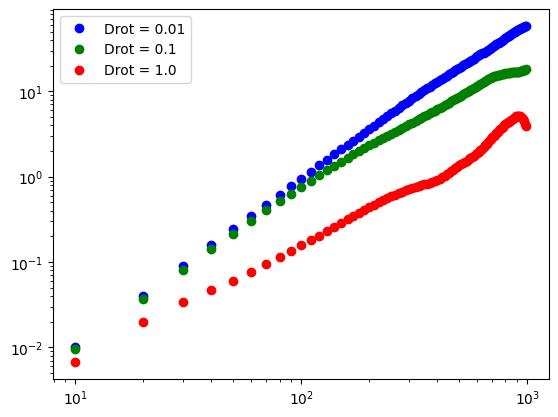

In [5]:
# obtain the trajectory
num_steps = 1000
drot_array = [0.01,0.1,1.0]
nplots = 3
tablesize = int(np.ceil(nplots/2))

plt.figure



x_coordinate, y_coordinate, theta_coordinate = get_trajectory(num_steps, 0.01, 1.0)
# define an interval over which you will evaluate MSD values 
interval=10
#define array which will contain MSD values
num_cases = int(round(num_steps/interval,1))
print(num_cases)
msd_1 = np.zeros(int(num_cases))
# Calculate MSD at every step, i.e. at every 100th value of n. 
# Refer to previous notebook for a method to calculate MSD
for n in range(0, num_steps, interval):
    i = int(n/interval)
    # The following is the key step! consider every possible interval of size n, and average over square of displacement
    msd_1[i] =  np.mean((x_coordinate[n:] - x_coordinate[:num_steps-n])**2 + (y_coordinate[n:] - y_coordinate[:num_steps-n])**2)

totalstep_values = np.arange(0, num_steps,interval)

x_coordinate, y_coordinate, theta_coordinate = get_trajectory(num_steps, 0.1, 1.0)
# define an interval over which you will evaluate MSD values 
interval=10
#define array which will contain MSD values
num_cases = int(round(num_steps/interval,1))
print(num_cases)
msd_2 = np.zeros(int(num_cases))
# Calculate MSD at every step, i.e. at every 100th value of n. 
# Refer to previous notebook for a method to calculate MSD
for n in range(0, num_steps, interval):
    i = int(n/interval)
    # The following is the key step! consider every possible interval of size n, and average over square of displacement
    msd_2[i] =  np.mean((x_coordinate[n:] - x_coordinate[:num_steps-n])**2 + (y_coordinate[n:] - y_coordinate[:num_steps-n])**2)

x_coordinate, y_coordinate, theta_coordinate = get_trajectory(num_steps, 1, 1.0)
# define an interval over which you will evaluate MSD values 
interval=10
#define array which will contain MSD values
num_cases = int(round(num_steps/interval,1))
print(num_cases)
msd_3 = np.zeros(int(num_cases))
# Calculate MSD at every step, i.e. at every 100th value of n. 
# Refer to previous notebook for a method to calculate MSD
for n in range(0, num_steps, interval):
    i = int(n/interval)
    # The following is the key step! consider every possible interval of size n, and average over square of displacement
    msd_3[i] =  np.mean((x_coordinate[n:] - x_coordinate[:num_steps-n])**2 + (y_coordinate[n:] - y_coordinate[:num_steps-n])**2)

totalstep_values = np.arange(0, num_steps,interval)


plt.loglog(totalstep_values, msd_1,'bo',label='Drot = 0.01'); plt.loglog(totalstep_values, msd_2,'go',label='Drot = 0.1'); plt.loglog(totalstep_values, msd_3,'ro',label='Drot = 1.0')
plt.legend()
    # for later: can you do without for loop? can you parallelize for loop?

        
    # plot msd vs number of steps (corresponds to time)
    
    

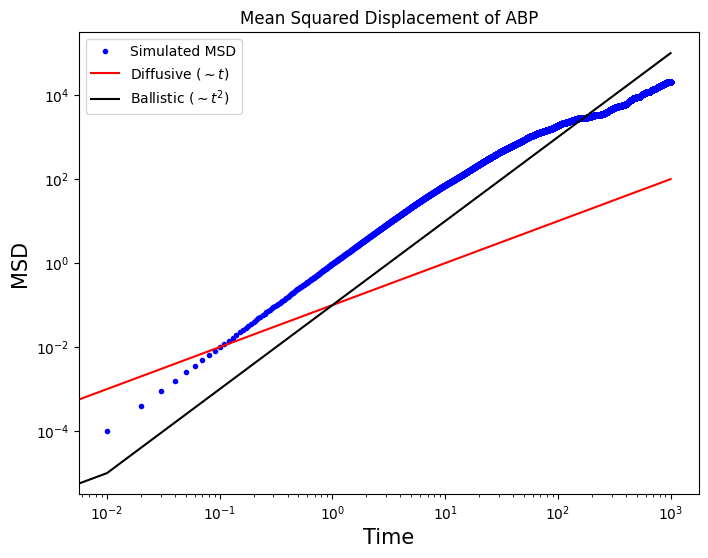

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation Parameters
num_steps = 10**5  # Long trajectory
num_walks = 100    # Number of walkers
dt = 0.01
Drot = 0.1  # Given rotational diffusion
vel = 1.0   # Particle velocity

# Initialize storage for multiple trajectories
xdata = np.zeros((num_walks, num_steps))
ydata = np.zeros((num_walks, num_steps))

# Generate multiple trajectories
for j in range(num_walks):
    x, y, theta = 0.0, 0.0, np.random.uniform(0, 2*np.pi)

    for i in range(num_steps):
        dtheta = np.sqrt(2 * Drot * dt) * np.random.randn()  # Rotational diffusion
        x += vel * dt * np.cos(theta)
        y += vel * dt * np.sin(theta)
        theta += dtheta  # Update orientation

        xdata[j, i] = x
        ydata[j, i] = y

# Compute Mean Squared Displacement (MSD)
time_at_step = np.linspace(0, num_steps * dt, num_steps)
msd_at_step = np.mean((xdata - xdata[:, 0][:, np.newaxis])**2 + 
                      (ydata - ydata[:, 0][:, np.newaxis])**2, axis=0)

# Define theoretical MSD lines
A, B = 0.1, 0.1  # Choose reasonable constants for scaling
msd_ballistic = A * time_at_step**2
msd_diffusive = B * time_at_step**1

# Plot MSD vs. time with theoretical models
plt.figure(figsize=(8, 6))
plt.loglog(time_at_step, msd_at_step, 'bo', markersize=3, label='Simulated MSD')
plt.loglog(time_at_step, msd_diffusive, 'r-', label=r'Diffusive ($\sim t$)')
plt.loglog(time_at_step, msd_ballistic, 'k-', label=r'Ballistic ($\sim t^2$)')

plt.xlabel("Time", fontsize=15)
plt.ylabel("MSD", fontsize=15)
plt.legend()
plt.title("Mean Squared Displacement of ABP")

plt.show()
